In [25]:
import json, os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

In [27]:
DATA = r"C:\Users\joshi\OneDrive\Desktop\combined.json"  

In [29]:
# Load dataset safely
with open(DATA, "r", encoding="utf-8") as f:
    data = json.load(f)

rows = []
for k, v in (data.items() if isinstance(data, dict) else enumerate(data)):
    if isinstance(v, dict):
        rec = {kk: v[kk] for kk in v if isinstance(v[kk], (int, float, str))}
        rec["title"] = str(v.get("report_title") or v.get("document_title") or k)
        rows.append(rec)
df = pd.DataFrame(rows)

In [31]:
# DATA CLEANING 
def safe_float(x):
    try:
        s = str(x).lower().replace(",", "").replace("%", "").strip()
        for w in ["hectares", "sqkm", "sq.km", "area", "ha", "km2"]:
            s = s.replace(w, "")
        return float(s)
    except:
        return np.nan

for col in df.columns:
    df[col] = df[col].apply(safe_float)

In [33]:
#VEGETATION DENSITY
def vegetation_density(row):
    """Auto-detect total and degraded area columns to compute vegetation density."""
    tot, waste = None, None
    for col in row.index:
        cname = col.lower()
        val = row[col]
        if pd.isna(val): 
            continue
        if ("total" in cname and "area" in cname) or ("geo" in cname and "area" in cname):
            tot = val
        if "waste" in cname or "degrad" in cname:
            waste = val
    if tot and waste and tot > 0:
        return max(0, 1 - waste / tot)
    return np.nan

df["density"] = df.apply(vegetation_density, axis=1)
df = df.dropna(subset=["density"])

C:\Users\joshi\AppData\Local\Temp\ipykernel_2560\2451056238.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["density"] = df.apply(vegetation_density, axis=1)


In [35]:
#NORMALIZATION
num_df = df.select_dtypes(include=[float, int]).fillna(0)
scaler = MinMaxScaler()
scaled = pd.DataFrame(scaler.fit_transform(num_df), columns=num_df.columns)

# Diagnostics
print("\nTotal Records:", len(df))
print("Detected Numeric Columns:", list(num_df.columns)[:10])
print("Vegetation Density Sample:\n", df["density"].head())


Total Records: 30
Detected Numeric Columns: ['report_title', 'total_geographical_area_hectares', 'pie_chart_percentage_1', 'pie_chart_percentage_2', 'pie_chart_percentage_3', 'pie_chart_percentage_4', 'pie_chart_percentage_5', 'pie_chart_percentage_6', 'land_degradation_class_sheet_erosion_slight_hectares', 'land_degradation_class_sheet_erosion_severe_hectares']
Vegetation Density Sample:
 0    0.999653
1    0.761303
2    0.999591
3    0.999907
4    0.000000
Name: density, dtype: float64


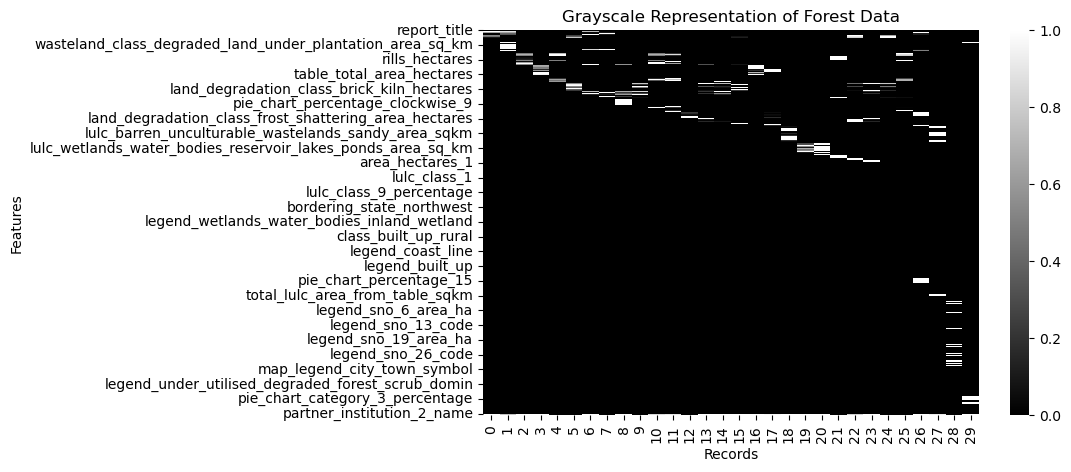

In [37]:
#GRAYSCALE REPRESENTATION
plt.figure(figsize=(8, 5))
sns.heatmap(scaled.T, cmap="gray", cbar=True)
plt.title("Grayscale Representation of Forest Data")
plt.xlabel("Records")
plt.ylabel("Features")
plt.show()

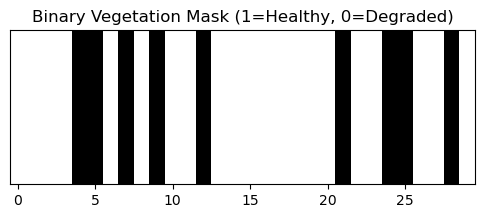

In [39]:
# Binary mask
threshold = scaled["density"].mean()
binary_mask = (scaled["density"] > threshold).astype(int)
plt.figure(figsize=(6, 2))
plt.imshow(binary_mask.values.reshape(1, -1), cmap="gray", aspect="auto")
plt.title("Binary Vegetation Mask (1=Healthy, 0=Degraded)")
plt.yticks([])
plt.show()

In [41]:
#MODEL TRAINING
X = scaled.drop(columns=["density"], errors="ignore")
y = scaled["density"]

if len(X) > 3:
    Xt, Xs, yt, ys = train_test_split(X, y, test_size=0.25, random_state=42)
else:
    Xt, Xs, yt, ys = X, X, y, y

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(Xt, yt)
preds = model.predict(Xs)

mse = mean_squared_error(ys, preds)
mae = mean_absolute_error(ys, preds)
r2 = r2_score(ys, preds)

print(f"\nModel Evaluation:\nMSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")



Model Evaluation:
MSE=0.1548, MAE=0.2666, R²=0.3134


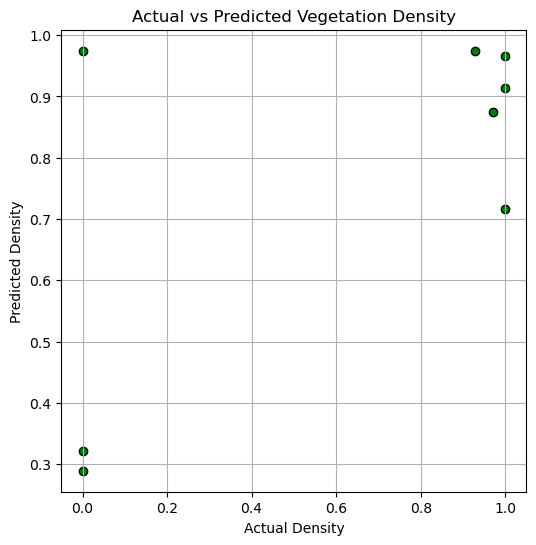

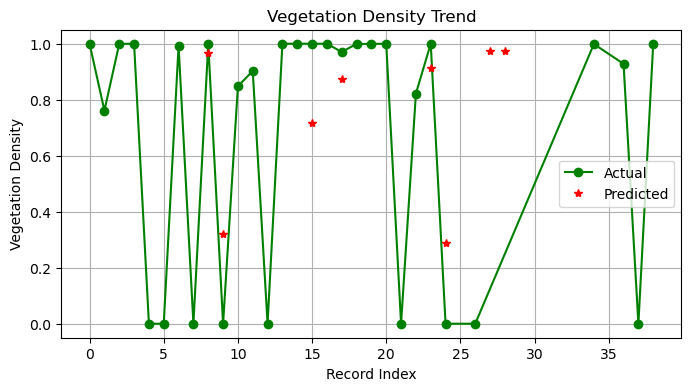

In [43]:
# VISUAL ANALYSIS
plt.figure(figsize=(6, 6))
plt.scatter(ys, preds, color="green", edgecolor="k")
plt.xlabel("Actual Density")
plt.ylabel("Predicted Density")
plt.title("Actual vs Predicted Vegetation Density")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df.index, df["density"], "go-", label="Actual")
plt.plot(Xs.index, preds, "r*", label="Predicted")
plt.xlabel("Record Index")
plt.ylabel("Vegetation Density")
plt.title("Vegetation Density Trend")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
#FOREST HEALTH SUMMARY
avg_density = df["density"].mean() * 100
if avg_density >= 80: status = "Excellent"
elif avg_density >= 60: status = "Good"
elif avg_density >= 40: status = "Moderate"
else: status = "Poor"

print(f"\nAverage Forest Health: {avg_density:.2f}% ({status})")


Average Forest Health: 67.40% (Good)
